# Hackathon Trading Pipeline

В этом ноутбуке мы не просто “что-то считаем”. Мы последовательно отвечаем на один практический вопрос:

**Если по данным рынка появляется сигнал купить или продать акцию, сколько мы реально заработаем после учёта стоимости исполнения?**

Логика ноутбука:

1. Берём 5-мин данные и строим сигнал: купить / продать / не трогать.
2. Проверяем сигнал на истории без издержек: это `pnl_mid`.
3. Берём 1-мин данные и оцениваем, насколько наша заявка будет двигать рынок против нас.
4. Разбиваем крупную заявку на минутные куски.
5. Считаем итог после издержек: это `pnl_net`.

Главный результат ноутбука — сравнение `pnl_mid` и `pnl_net`, а также таблицы `signal_5min`, `execution_schedule` и `execution_summary`.

In [47]:
import importlib

import pandas as pd
import matplotlib.pyplot as plt

import src.data
import src.formal_pipeline

importlib.reload(src.data)
importlib.reload(src.formal_pipeline)

from src.formal_pipeline import FormalHackathonPipeline

## Параметры запуска pipeline

`data_root` — папка с parquet-данными.

`delta` — минимальная сила сигнала. Если `abs(signal) < delta`, позицию не открываем. Это фильтр слабых сигналов.

`impact_a` — базовый коэффициент рыночного импакта. По ТЗ ориентир `a` находится в диапазоне `[0.01, 0.05]`, поэтому берём середину `0.03`.

`aum_rub` — условный размер портфеля в рублях. Через него переводим относительные позиции в денежный объём исполнения.

`x_max` — максимальная доля нашего объёма от рыночного объёма за минуту. `0.30` значит, что в одном 1-мин слайсе мы не хотим занимать больше 30% рынка.

`top_n=None` — не ограничиваемся фиксированным числом акций. Это ближе к ТЗ: работаем со всем universe после фильтра ликвидности.

`min_avg_volume` — минимальный средний рыночный объём. Неликвидные тикеры отбрасываются, потому что их дорого и нестабильно исполнять.

`ema_span` — окно EMA-сглаживания для сигнала. Это нужно, чтобы сигнал реагировал на устойчивое давление покупателей/продавцов, а не на шум одного бара.

## Шаг 0. Запускаем весь pipeline

Эта ячейка запускает все этапы сразу. На выходе объект `result`, в котором лежат все таблицы из формального ТЗ.

Как читать метрики:

- `pnl_mid_total` — сколько получилось бы в идеальном мире без стоимости исполнения.
- `pnl_net_total` — сколько осталось после учёта импакта.
- `avg_is_reduction` — насколько наше расписание исполнения снижает implementation shortfall относительно простого TWAP.
- `hit_rate_mid` — как часто сигнал давал положительный результат до учёта издержек.

In [48]:
pipeline = FormalHackathonPipeline(
    data_root="insample_data",
    delta=0.10,
    impact_a=0.03,
    aum_rub=50_000_000,
    x_max=0.30,
    top_n=None,
    min_avg_volume=100_000,
    ema_span=6,
)

result = pipeline.run(max_execution_bars=1000)

result.metrics

signal_rows         1.240320e+05
execution_rows      3.156200e+04
pnl_mid_total       2.129821e-01
pnl_net_total      -8.172972e+07
sharpe_net         -3.380682e+02
hit_rate_mid        5.575980e-01
avg_is_reduction    5.027836e-01
dtype: float64

## Формальный pipeline по уточнённому ТЗ

Решение разбито на независимые таблицы модулей: `signal_5min`, `backtest_baseline`, `impact_model`, `execution_schedule`, `execution_summary`.

Что теперь ближе к ТЗ:

- сигнал строится на 5-мин барах;
- исполнение моделируется 1-мин слайсами внутри 5-мин бара;
- universe не ограничен фиксированными 8/38 акциями, а выбирается по ликвидности;
- сигнал использует EMA-сглаживание признаков;
- позиции нормируются long/short, чтобы быть ближе к рублёвой нейтральности портфеля.

In [49]:
print("signal_5min", result.signal_5min.shape)
print("backtest_baseline", result.backtest_baseline.shape)
print("impact_model", result.impact_model.shape)
print("execution_schedule", result.execution_schedule.shape)
print("execution_summary", result.execution_summary.shape)

signal_5min (124032, 3)
backtest_baseline (124032, 5)
impact_model (446210, 4)
execution_schedule (125783, 6)
execution_summary (31562, 10)


## Шаг 1. Получаем торговый сигнал

Вопрос этого шага: **какую акцию купить, какую продать, а какую не трогать?**

Таблица `signal_5min` отвечает на этот вопрос для каждого 5-мин бара и тикера.

Как читать колонку `value`:

- ближе к `1` — хотим купить;
- ближе к `-1` — хотим продать;
- около `0` — лучше не трогать.

In [50]:
result.signal_5min.head(20)

,bar_end_ts,seccode,value
0,1725271500000000,FEES,-0.562406
1,1725271500000000,SGZH,0.592311
2,1725271500000000,AKMM,0.982440
3,1725271500000000,UNAC,0.866700
4,1725271500000000,HYDR,0.901514
5,1725271500000000,AKMB,0.197395
6,1725271500000000,KUZB,-0.982144
7,1725271500000000,SBSC,-0.100160
8,1725271500000000,ELMT,-0.264402
9,1725271500000000,SIPO,0.753108


## Шаг 2. Проверяем сигнал на истории

Вопрос этого шага: **если бы мы следовали этим сигналам раньше, был бы результат?**

Таблица `backtest_baseline` показывает идеальную проверку без издержек.

Как читать:

- `pos` — позиция, которую держим на следующем 5-мин баре;
- `pnl_mid` — прибыль/убыток без учёта стоимости исполнения;
- `cum_pnl_mid` — накопленный результат.

Важно: сигнал применяется со сдвигом на следующий бар, поэтому мы не смотрим в будущее.

In [51]:
result.backtest_baseline.head()

,bar_end_ts,seccode,pos,pnl_mid,cum_pnl_mid
0,1725271500000000,FEES,0.0,0.0,0.0
1,1725271500000000,SGZH,0.0,-0.0,-0.0
2,1725271500000000,AKMM,0.0,0.0,0.0
3,1725271500000000,UNAC,0.0,-0.0,-0.0
4,1725271500000000,HYDR,0.0,-0.0,-0.0


## Шаг 3. Оцениваем рыночный импакт

Вопрос этого шага: **насколько наши сделки будут портить цену?**

Таблица `impact_model` строится по 1-мин данным. Она показывает, какой был рыночный объём в минуту и какой коэффициент импакта `a` используем.

Как читать:

- `volume_mkt` — сколько всего торговали по инструменту за минуту;
- `a` — насколько дорогим становится наше исполнение при большой доле участия;
- чем меньше `volume_mkt`, тем опаснее исполнять крупную заявку в эту минуту.

In [52]:
result.impact_model.head()

,bar_end_ts,seccode,volume_mkt,a
0,1725271260000000,FEES,24620000,0.023333
1,1725271260000000,SGZH,12200700,0.028750
2,1725271260000000,AKMM,427760,0.030417
3,1725271260000000,UNAC,1087000,0.025833
4,1725271260000000,HYDR,4934000,0.025417


## Шаг 4. Строим расписание исполнения

Вопрос этого шага: **как именно купить или продать нужный объём?**

Мы не исполняем всё сразу. Для каждого 5-мин бара берём 1-мин слайсы и распределяем объём по ним.

Таблица `execution_schedule` показывает детальный план исполнения.

Как читать:

- `bar_end_ts_5min` — к какому 5-мин решению относится исполнение;
- `bar_end_ts_1min` — конкретная минута исполнения;
- `q_slice` — сколько покупаем или продаём в эту минуту;
- `participation_rate` — какую долю рынка занимает наша сделка;
- `impact_cost_rel` — относительная стоимость импакта в этой минуте.

In [53]:
result.execution_schedule.head(10)

,bar_end_ts_5min,bar_end_ts_1min,seccode,q_slice,participation_rate,impact_cost_rel
0,1725271800000000000,1725271560000000,FEES,-4.051972e+06,0.073632,0.001858
1,1725271800000000000,1725271620000000,FEES,-1.424210e+06,0.079255,0.001858
2,1725271800000000000,1725271680000000,FEES,-1.330455e+06,0.073384,0.001858
3,1725271800000000000,1725271740000000,FEES,-4.682453e+06,0.073083,0.001858
4,1725271800000000000,1725271800000000,FEES,-1.300367e+06,0.073384,0.001858
5,1725271800000000000,1725271560000000,SGZH,2.245912e+05,0.059763,0.001834
6,1725271800000000000,1725271620000000,SGZH,2.054975e+05,0.061122,0.001834
7,1725271800000000000,1725271680000000,SGZH,1.052453e+05,0.060181,0.001834
8,1725271800000000000,1725271740000000,SGZH,1.834276e+05,0.060284,0.001834
9,1725271800000000000,1725271800000000,SGZH,3.458466e+05,0.063093,0.001834


## Шаг 5. Считаем итог исполнения

Вопрос этого шага: **что осталось от прибыли после реального исполнения?**

Таблица `execution_summary` агрегирует минутные слайсы обратно на уровень 5-мин решения.

Самые важные колонки:

- `pnl_mid` — идеальная прибыль без импакта;
- `implementation_shortfall` — сколько потеряли из-за того, что сделка двигала рынок;
- `pnl_net` — итог после издержек;
- `is_reduction` — насколько наше расписание лучше простого TWAP.

Главная формула:

```python
pnl_net = pnl_mid - implementation_shortfall
```

In [54]:
result.execution_summary.head()

,bar_end_ts_5min,seccode,Q_executed,vwap_fill,twap_bench,implementation_shortfall,implementation_shortfall_twap,is_reduction,pnl_mid,pnl_net
0,1725271800000000000,FEES,1.278946e+07,0.088613,0.088522,2109.097302,2893.349462,0.271053,-6163.939368,-8273.036670
1,1725271800000000000,SGZH,1.064608e+06,1.120886,1.121675,2184.102007,2528.332978,0.136149,-1071.285843,-3255.387850
2,1725271800000000000,AKMM,1.505100e+04,126.913189,126.941314,18060.035750,18487.354630,0.023114,157.745136,-17902.290613
3,1725271800000000000,UNAC,1.500600e+06,0.610714,0.615896,7752.239586,14925.485999,0.480604,-14374.670679,-22126.910265
4,1725271800000000000,HYDR,1.276800e+06,0.519565,0.523061,5217.731272,9449.020344,0.447802,353.402178,-4864.329094


## Шаг 6. Смотрим итоговый график

Вопрос этого шага: **как менялся результат стратегии во времени?**

На графике:

- `baseline pnl_mid` — идеальный результат без стоимости исполнения;
- `net pnl after IS` — результат после учёта implementation shortfall;
- ось X — номер 30-мин бара, как в презентации;
- ось Y — накопленный PnL в процентах от AUM.

Если `pnl_net` сильно ниже `pnl_mid`, значит издержки исполнения съедают результат сигнала.

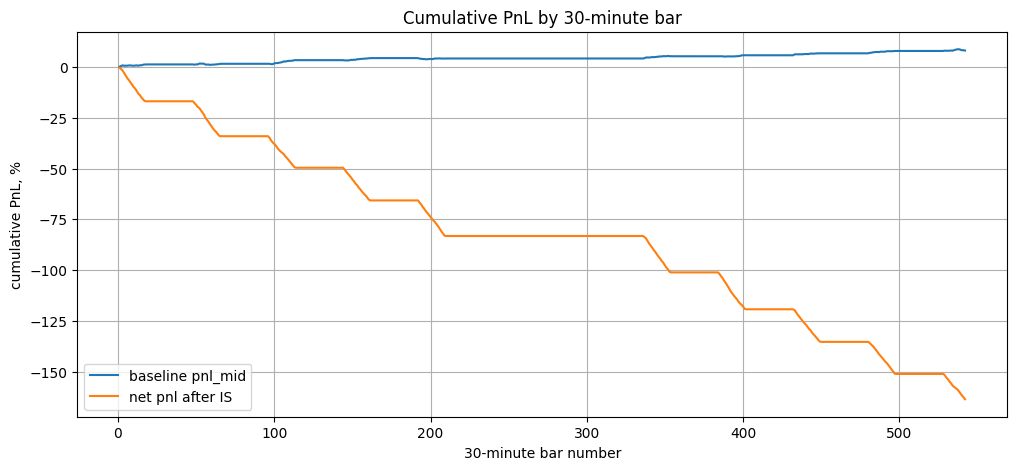

In [55]:
aum_rub = pipeline.aum_rub

plot_df = result.execution_summary.copy()
plot_df["bar_end_dt"] = pd.to_datetime(plot_df["bar_end_ts_5min"])

# The signal is 5-minute, but the presentation chart is shown by 30-minute bars.
plot_30m = (
    plot_df
    .set_index("bar_end_dt")[["pnl_mid", "pnl_net"]]
    .resample("30min")
    .sum()
    .dropna(how="all")
)
plot_30m = plot_30m / aum_rub * 100
plot_30m = plot_30m.cumsum().reset_index(drop=True)
plot_30m.index = plot_30m.index + 1

fig, ax = plt.subplots(figsize=(12, 5))
plot_30m["pnl_mid"].plot(ax=ax, label="baseline pnl_mid")
plot_30m["pnl_net"].plot(ax=ax, label="net pnl after IS")
ax.set_title("Cumulative PnL by 30-minute bar")
ax.set_xlabel("30-minute bar number")
ax.set_ylabel("cumulative PnL, %")
ax.grid(True)
ax.legend()
plt.show()

## Шаг 7. Финальная диагностика

Здесь смотрим распределение ключевых величин по исполнению:

- средний `implementation_shortfall`;
- средний `pnl_mid`;
- средний `pnl_net`;
- насколько часто и насколько сильно оптимизированное расписание лучше TWAP.

Эта таблица нужна не для принятия отдельной сделки, а для общего вывода: **стратегия после учёта исполнения выглядит устойчиво или нет**.

In [56]:
is_cols = [
    "implementation_shortfall",
    "implementation_shortfall_twap",
    "is_reduction",
    "pnl_mid",
    "pnl_net",
]

result.execution_summary[is_cols].describe()

,implementation_shortfall,implementation_shortfall_twap,is_reduction,pnl_mid,pnl_net
count,31562.000000,3.156200e+04,31562.000000,31562.000000,31562.000000
mean,2716.683888,2.103628e+05,0.502784,127.186546,-2589.497342
std,4048.043305,1.004625e+07,0.334619,4830.925779,6341.050713
min,0.010654,1.065389e-02,-0.040042,-140236.388853,-155861.802016
25%,36.604220,9.864575e+01,0.204511,-970.327777,-4829.369800
50%,688.832421,2.366510e+03,0.516116,0.000000,-871.678716
75%,3858.720540,1.233250e+04,0.816921,1193.117911,-0.031461
max,22929.013113,1.280282e+09,0.999997,153785.574614,152652.755020
